In [3]:
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.stats import linregress
from itertools import combinations
import numpy as np
from sklearn.linear_model import LinearRegression
from itertools import combinations


In [4]:
df = pd.read_csv('/Users/juar705/Library/Group Containers/UBF8T346G9.OneDriveStandaloneSuite/OneDrive - PNNL.noindex/OneDrive - PNNL/Documents/P_putida_AG5577_baseline/Round1/mapped_data_2025-04-15_biotek_final_od_data.csv')
ingredient_columns = [
    'd_glucose', 'sodium_acetate', 'sodium_citrate', 'sodium_octanoate', 'sodium_benzoate',
    'sodium_chloride', 'potassium_chloride'
]
growth_column = 'y'
df = df.dropna(subset=ingredient_columns + [growth_column]).reset_index(drop=True)
od600 = df['y'].values

substrate_concentrations = {
    "glucose": df["d_glucose"].values,
    "sodium_acetate": df["sodium_acetate"].values,
    "sodium_citrate": df["sodium_citrate"].values,
    "sodium_octanoate": df["sodium_octanoate"].values,
    "sodium_benzoate": df["sodium_benzoate"].values,
    "sodium_chloride": df["sodium_chloride"].values,
    "potassium_chloride": df["potassium_chloride"].values,
}
salt_concentrations = {
    "sodium_chloride": df["sodium_chloride"].values,
    "potassium_chloride": df["potassium_chloride"].values,
}

conversion_factors = {
    "glucose": 0.5,
    "sodium_octanoate": 0.8,
    "sodium_benzoate": 0.25,
    "sodium_citrate": 0.38,
    "sodium_acetate": 0.27,
    "sodium_chloride": 0.5,
    "potassium_chloride": 0.6,
}
# mmol/gDW/hr
uptake_rates = {
    "glucose": 4.002,
    "sodium_octanoate": 3.006,
    "sodium_benzoate": 3.453,
    "sodium_citrate": 4.002,
    "sodium_acetate": 12.004,
    "sodium_chloride": 0.01,  
    "potassium_chloride": 0.0953, 
}
# yield coefficients are actually Biomass growth rate to convert to coefficeint it has to be divided by the uptake rate which is done in the function.
biomass_growth_rate = {
    "glucose": 0.586,
    "sodium_octanoate": 1.08,
    "sodium_benzoate": 0.896,
    "sodium_citrate": 0.89,
    "sodium_acetate": 0.925,
    "sodium_chloride": 0.586, 
    "potassium_chloride": 0.586, 
}

#  mmol/L

ingredients = ['glucose', 'sodium_octanoate', 'sodium_benzoate', 'sodium_citrate', 'sodium_acetate', 'sodium_chloride', 'potassium_chloride']
salts = ['sodium_chloride', 'potassium_chloride']

pH  = df['pH'].values
ic50 = {
    "sodium_chloride" : 1.80,
    "potassium_chloride": 1.43
}


In [5]:
def compute_modeled_od600_w_limiting(
    df, ingredients, conversion_factors, uptake_rates, biomass_growth_rate, ic50, combinations,
    substrate_concentrations, pH_column):
    
    """
    Compute modeled OD600 values based on substrate concentrations, pH, and Delta OD600 values.

    Parameters:
    df: Data frame containing substrate concentrtions, pH and Delta OD600 values (y)
    ingredients: list of ingredients to use for modeling
    conversion_factors: dict mapping ingredients to their conversion factors. (obtained from literature)
    uptake_rates: dict mapping ingredients to their uptake rates (mmol/gDW/hr). (obtained from Cobrapy p. pututda iJN1463 model)
    biomass_growth_rate: dict mapping ingredients to their biomass growth rates (gDW/mmol). (obtained from Coprapy p. pututda iJN1463 model)
    ic50: dict mapping salts to their IC50 values (mmol/L). (obtained from literature)
    combinations: list of tuples containing combinations of ingredients to model.
    substrate_concentrations: dict mapping ingredients to their concentrations in the dataframe.
    pH_column: str, name of the column in df containing pH values.
    Returns:
        df_modeled_od600: DataFrame containing modeled OD600 values for each ingredient and combination.
        df_biomass_salt: DataFrame containing effective biomass and salt penalty values for each ingredient and combination that will be used for growth simulations.
    """
    
    modeled_od600_dict = {}
    effective_biomass_dict = {}
    salt_penalty_dict = {}

    ph_optimal = 7.0
    ph_stdv = 1.0

    for i in ingredients:
        substrate_conc = substrate_concentrations[i]
        conversion_factor = conversion_factors[i]
        uptake_rate = uptake_rates[i] 
        biomass_growth = biomass_growth_rate[i]

        biomass = substrate_conc * (biomass_growth / uptake_rate) #(in parentheses will calculate for yield coefficient)
        pH_factor = np.exp(-((pH - ph_optimal) ** 2) / (2 * ph_stdv ** 2))
        if i not in salts:
            salt_penalty = np.full_like(biomass, 1)  
            effective_biomass = biomass * pH_factor
        else:
            salt_penalty = np.ones_like(biomass) 
            for j in salts:
                IC50_value = ic50[j]
                salt_penalty_constant = 1 / (10 ** IC50_value)
                salt_conc = salt_concentrations[j]
                salt_penalty = salt_penalty * 1 / (1 + (salt_conc * IC50_value))
            effective_biomass = biomass * pH_factor * salt_penalty
            
        od600_cdw = od600 * conversion_factor 
        slope, intercept, *_ = linregress(biomass, od600_cdw)
        modeled_od600 = slope * biomass + intercept

        modeled_od600_dict[f'modeled_od600_{i}'] = modeled_od600
        effective_biomass_dict[f'effective_biomass_{i}'] = effective_biomass
        salt_penalty_dict[f'salt_penalty_{i}'] = salt_penalty if i in salts else np.full_like(biomass, 0.1)

    # For combos
    combo_od600_dict = {}
    combo_biomass_dict = {}
    combo_salt_dict = {}
    for combo in combinations:
        combo_name = '+'.join(combo)
        modeled_ods = np.stack([modeled_od600_dict[f'modeled_od600_{s}'] for s in combo], axis=1)
        combo_od600_dict[f'modeled_od600_{combo_name}_sum'] = np.sum(modeled_ods, axis=1)
        combo_biomass_dict[f'effective_biomass_{combo_name}'] = np.sum([effective_biomass_dict[f'effective_biomass_{s}'] for s in combo], axis=0)
        combo_salt_dict[f'salt_penalty_{combo_name}'] = np.sum([salt_penalty_dict[f'salt_penalty_{s}'] for s in combo], axis=0)

    # Build new DataFrames
    df_modeled_od600 = pd.DataFrame(modeled_od600_dict)
    df_modeled_od600 = pd.concat([df_modeled_od600, pd.DataFrame(combo_od600_dict)], axis=1)

    df_biomass_salt = pd.DataFrame(effective_biomass_dict)
    df_biomass_salt = pd.concat([df_biomass_salt, pd.DataFrame(combo_biomass_dict)], axis=1)
    df_biomass_salt = pd.concat([df_biomass_salt, pd.DataFrame(salt_penalty_dict)], axis=1)
    df_biomass_salt = pd.concat([df_biomass_salt, pd.DataFrame(combo_salt_dict)], axis=1)

    return df_modeled_od600, df_biomass_salt

carbon_combos = []
for r in range(2, len(ingredients) + 1):
    carbon_combos.extend(list(combinations(ingredients, r)))

df_modeled_od600, df_biomass_salt = compute_modeled_od600_w_limiting(
    df, ingredients, conversion_factors, uptake_rates, biomass_growth_rate,
    ic50, carbon_combos, substrate_concentrations, pH_column='pH'
)

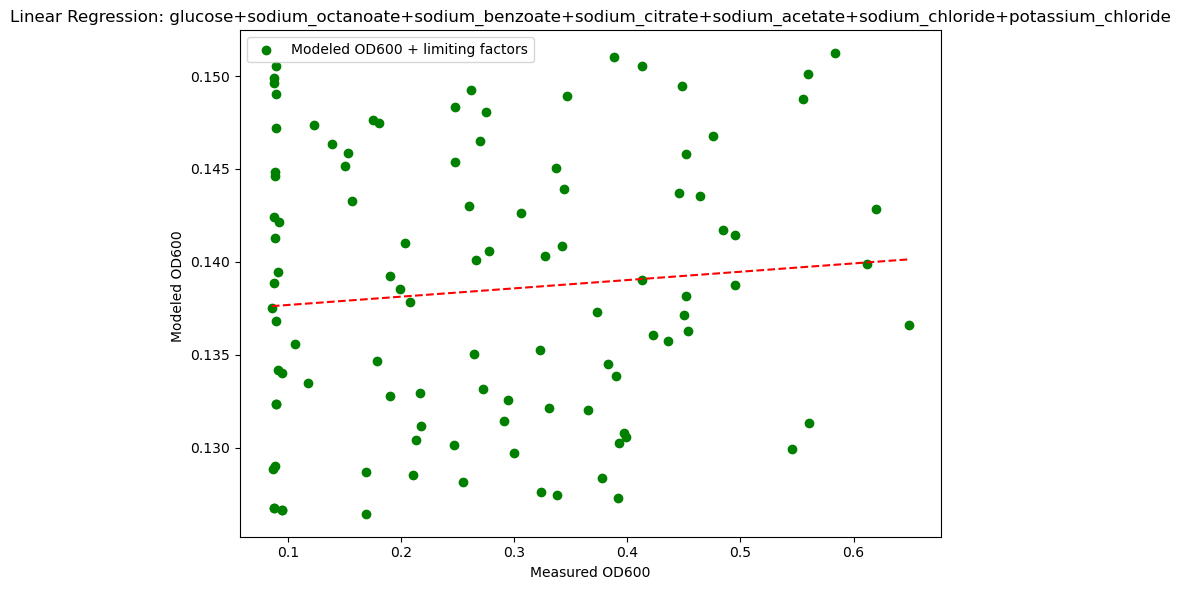

In [26]:
#combo_name = 'glucose+sodium_octanoate+sodium_benzoate+sodium_citrate+sodium_acetate+sodium_chloride+potassium_chloride'
individual_ing = 'glucose'
x = od600
y = df_modeled_od600[f'modeled_od600_{combo_name}_sum']
y = df_modeled_od600[f'modeled_od600_{individual_ing}']
if isinstance(y, pd.DataFrame):
	y = y.iloc[:, 0]
slope, intercept = linregress(x, y)[:2]
x_fit = np.linspace(x.min(), x.max(), 103)
y_fit = slope * x_fit + intercept

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color = 'green', label = 'Modeled OD600 + limiting factors')
plt.plot(x_fit, y_fit, color='red', linestyle='dashed')
plt.xlabel('Measured OD600')
plt.ylabel(f'Modeled OD600 ')
plt.title(f'Linear Regression: {combo_name}')
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
def simulate_growth(
    df_biomass_salt, df_modeled_od600, substrate_concentrations, uptake_rates, hours, excluded_ingredients=None
):
    """
    Simulates microbial growth based on effective biomass values, substrate consumption,
    and environmental factors (pH and salts).
    
    Parameters:
    df_biomass_salt: DataFrame containing effective biomass values for different ingredients. from compute_modeled_od600_w_limiting function.
    substrate_concentrations: dict mapping ingredients to their concentrations in the DataFrame.
    uptake_rates: dict mapping ingredients to their uptake rates (mmol/gDW/hr).
    hours: int, number of hours to simulate growth.
    excluded_ingredients: list of ingredients to exclude from the simulation.

    """
    growth_curves = {}
    included_columns = [
        col for col in df_biomass_salt.columns
        if col.startswith('effective_biomass_') and (excluded_ingredients is None or col not in excluded_ingredients)
    ]
    for column in included_columns:
        ingredient_key = column.replace('effective_biomass_', '')
        ingredient_list = ingredient_key.split('+')
        
        if '+' in ingredient_key:
            modeled_od600_col = f"modeled_od600_{ingredient_key}_sum"
        else:
            modeled_od600_col = f"modeled_od600_{ingredient_key}"
        uptake_rate = sum([uptake_rates.get(ing, 0) for ing in ingredient_list])
        effective_biomass = df_biomass_salt[column].values
        salt_penalty = df_biomass_salt.get(f'salt_penalty_{ingredient_key}', 1).values
        
        for i in range(len(effective_biomass)):
            
            # Get modeled OD600 for this sample
            mu_max = effective_biomass[i] * salt_penalty[i]  
            #modeled_od600 = df_modeled_od600[modeled_od600_col].iloc[i] #this is another option to simulate growth with effective biomass calculations using final modeled OD600 values
            #this code could also be used to implement the logistic growth eqation
            mu_max = mu_max * salt_penalty[i]
            Ks = mu_max / 2
            
            local_substrate = {ing: float(substrate_concentrations.get(ing, np.zeros(len(effective_biomass)))[i]) for ing in ingredient_list}
            substrate_available = sum(local_substrate.values())
            biomass = 0.08
            curve = []
            for t in range(hours):
                if substrate_available > 0:
                    growth_rate = mu_max * (substrate_available / (Ks + substrate_available))

                    increment = growth_rate * biomass
                    biomass = biomass + increment
                    actual_uptake = min(substrate_available, uptake_rate)
                    substrate_available = substrate_available - actual_uptake * biomass * t
                else:
                    break
                curve.append(biomass)
            # Pad curve to full simulation length if substrate depletes early and convert biomass to OD600
            if len(curve) < hours:
                curve = curve + [biomass] * (hours - len(curve))
            od600_curve = [b / conversion_factors.get(ingredient_key, 1) for b in curve]
            curve_key = f"{column}, Experiment {i+1}"
            growth_curves[curve_key] = od600_curve
    return growth_curves

growth_curves = simulate_growth(df_biomass_salt=df_biomass_salt, df_modeled_od600=df_modeled_od600, substrate_concentrations=substrate_concentrations, 
                                uptake_rates=uptake_rates, hours=24, excluded_ingredients=None)

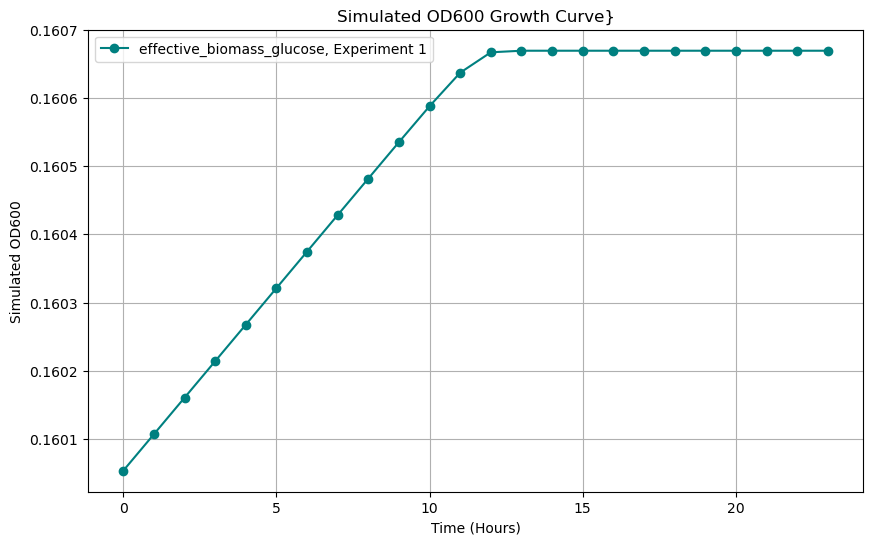

In [31]:

ingredient_key = "glucose"
experiment_number = 1

# Build the correct key for growth_curves
curve_key = f"effective_biomass_{ingredient_key}, Experiment {experiment_number}"

# Plot the OD600 curve for the selected experiment
plt.figure(figsize=(10, 6))
plt.plot(growth_curves[curve_key], marker='o', color='teal', label=curve_key)
plt.xlabel('Time (Hours)')
plt.ylabel('Simulated OD600')
plt.title("Simulated OD600 Growth Curve}")
plt.grid(True)
plt.legend()
plt.show()